# VisionInspect — 02 Prepare YOLO Segmentation Dataset

Convert DAGM, KolektorSDD2 and Magnetic Tile masks into **YOLO instance-segmentation** labels.

Raw data is read from relative paths under:

```text
datasets/
```

Generated data is written to:

```text
datasets/yolo_segmentation/
```

The raw datasets are never modified.

**Policy:** keep disconnected contours as separate polygons; do not apply an arbitrary minimum-area filter; simplify polygons with configurable `approxPolyDP`; reject only geometrically invalid polygons.


In [19]:
from pathlib import Path
import random
import shutil

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_ROOT = Path("datasets")

SOURCE_ROOTS = {
    "DAGM": DATA_ROOT / "DAGM",
    "KolektorSDD2": DATA_ROOT / "KolektorSDD2",
    "Magnetic Tile": DATA_ROOT / "magnetic_tile",
}

OUTPUT_ROOT = DATA_ROOT / "yolo_segmentation"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

APPROX_EPSILON_RATIO = 0.002
MIN_POLYGON_POINTS = 3

MAGNETIC_SPLIT_RATIOS = {"train": 0.70, "val": 0.15, "test": 0.15}

print("Dataset root:", DATA_ROOT.resolve())
print("Output root:", OUTPUT_ROOT.resolve())


Dataset root: /home/zubair/AI Development Directory/anomaly-detection/datasets
Output root: /home/zubair/AI Development Directory/anomaly-detection/datasets/yolo_segmentation


## 1. Mask → YOLO polygon conversion

In [20]:
def mask_to_yolo_polygons(mask, class_id,
                            epsilon_ratio=APPROX_EPSILON_RATIO,
                            min_points=MIN_POLYGON_POINTS):
    if mask is None:
        return [], {"raw_contours": 0, "valid_polygons": 0, "discarded_polygons": 0}

    binary = (mask > 0).astype(np.uint8)
    contours, _ = cv2.findContours(
        binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    h, w = mask.shape[:2]
    polygons = []
    discarded = 0

    for contour in contours:
        if len(contour) < 3:
            discarded += 1
            continue

        perimeter = cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(
            contour, epsilon_ratio * perimeter, True
        )
        points = approx.reshape(-1, 2)

        if len(points) < min_points:
            discarded += 1
            continue

        coords = []
        for x, y in points:
            coords.extend([
                float(np.clip(x / w, 0.0, 1.0)),
                float(np.clip(y / h, 0.0, 1.0)),
            ])

        polygons.append([int(class_id), *coords])

    polygons.sort(key=lambda p: (p[1], p[2]))

    return polygons, {
        "raw_contours": len(contours),
        "valid_polygons": len(polygons),
        "discarded_polygons": discarded,
    }


def read_mask(path):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Cannot read mask: {path}")
    return mask


## 2. Dataset discovery helpers

In [21]:
def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None


def validate_image_path(path):
    return path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS


## 3. DAGM adapter

DAGM classes are mapped to class IDs 0–9. Images without a corresponding `Label` mask are retained as normal samples and receive an empty YOLO label file.

In [22]:
DAGM_CLASSES = [f"Class{i}" for i in range(1, 11)]
DAGM_CLASS_TO_ID = {name: i for i, name in enumerate(DAGM_CLASSES)}


def find_dagm_pairs(root):
    rows = []

    for class_name in DAGM_CLASSES:
        class_root = root / class_name
        if not class_root.exists():
            print("WARNING:", class_root, "not found")
            continue

        for split_name, split_key in [("Train", "train"), ("Test", "test")]:
            split_root = class_root / split_name
            if not split_root.exists():
                print("WARNING:", split_root, "not found")
                continue

            label_dir = first_existing([
                split_root / "Label",
                split_root / "label",
                split_root / "labels",
            ])

            for image_path in sorted(split_root.rglob("*")):
                if not validate_image_path(image_path):
                    continue
                if image_path.parent.name.lower() in {"label", "labels"}:
                    continue

                mask_path = None
                if label_dir is not None:
                    mask_path = first_existing([
                        label_dir / f"{image_path.stem}.png",
                        label_dir / f"{image_path.stem}_Label.PNG",
                        label_dir / f"{image_path.stem}_label.PNG",
                        label_dir / f"{image_path.stem}_Label.png",
                        label_dir / f"{image_path.stem}_label.png",
                    ])

                rows.append({
                    "dataset": "DAGM",
                    "source_class": class_name,
                    "class_id": DAGM_CLASS_TO_ID[class_name],
                    "split": split_key,
                    "image_path": image_path,
                    "mask_path": mask_path,
                })

    return pd.DataFrame(rows)


dagm = find_dagm_pairs(SOURCE_ROOTS["DAGM"])
print("DAGM images:", len(dagm))
print("DAGM images with masks:", dagm["mask_path"].notnull().sum())
display(dagm.head())


DAGM images: 16100
DAGM images with masks: 2100


,dataset,source_class,class_id,split,image_path,mask_path
0,DAGM,Class1,0,train,datasets/DAGM/Class1/Train/0576.PNG,None
1,DAGM,Class1,0,train,datasets/DAGM/Class1/Train/0577.PNG,None
2,DAGM,Class1,0,train,datasets/DAGM/Class1/Train/0578.PNG,None
3,DAGM,Class1,0,train,datasets/DAGM/Class1/Train/0579.PNG,None
4,DAGM,Class1,0,train,datasets/DAGM/Class1/Train/0580.PNG,None


## 4. KolektorSDD2 adapter

`*_GT` files are masks and are never treated as input images. Images without a GT mask are retained as normal samples.

In [23]:
def find_kolektor_pairs(root):
    rows = []

    for split in ["train", "test"]:
        split_root = root / split
        if not split_root.exists():
            print("WARNING:", split_root, "not found")
            continue

        for image_path in sorted(split_root.rglob("*")):
            if not validate_image_path(image_path):
                continue
            if "_GT" in image_path.stem:
                continue

            mask_path = first_existing([
                image_path.with_name(f"{image_path.stem}_GT{image_path.suffix}"),
                image_path.with_name(f"{image_path.stem}_GT.png"),
                image_path.with_name(f"{image_path.stem}_GT.bmp"),
            ])

            rows.append({
                "dataset": "KolektorSDD2",
                "source_class": "defect",
                "class_id": 0,
                "split": split,
                "image_path": image_path,
                "mask_path": mask_path,
            })

    return pd.DataFrame(rows)


kolektor = find_kolektor_pairs(SOURCE_ROOTS["KolektorSDD2"])
print("KolektorSDD2 images:", len(kolektor))
print("KolektorSDD2 images with masks:", kolektor["mask_path"].notnull().sum())
display(kolektor.head())


KolektorSDD2 images: 3336
KolektorSDD2 images with masks: 3335


,dataset,source_class,class_id,split,image_path,mask_path
0,KolektorSDD2,defect,0,train,datasets/KolektorSDD2/train/10000.png,datasets/KolektorSDD2/train/10000_GT.png
1,KolektorSDD2,defect,0,train,datasets/KolektorSDD2/train/10001.png,datasets/KolektorSDD2/train/10001_GT.png
2,KolektorSDD2,defect,0,train,datasets/KolektorSDD2/train/10002.png,datasets/KolektorSDD2/train/10002_GT.png
3,KolektorSDD2,defect,0,train,datasets/KolektorSDD2/train/10003.png,datasets/KolektorSDD2/train/10003_GT.png
4,KolektorSDD2,defect,0,train,datasets/KolektorSDD2/train/10004.png,datasets/KolektorSDD2/train/10004_GT.png


## 5. Magnetic Tile adapter

Source classes are `Blowhole`, `Break`, `Crack`, `Fray`, `Uneven`, and `Free`. `Free` is normal/background and is **not** a segmentation class.

In [24]:
MAGNETIC_CLASSES = ["Blowhole", "Break", "Crack", "Fray", "Uneven"]
MAGNETIC_CLASS_TO_ID = {name: i for i, name in enumerate(MAGNETIC_CLASSES)}


def find_magnetic_pairs(root):
    rows = []

    for class_name in MAGNETIC_CLASSES + ["Free"]:
        class_root = root / class_name
        if not class_root.exists():
            class_root = root / f"MT_{class_name}"

        if not class_root.exists():
            print("WARNING:", class_name, "directory not found")
            continue

        for image_path in sorted(class_root.rglob("*")):
            if image_path.suffix.lower() not in {".jpg", ".jpeg"}:
                continue

            mask_path = image_path.with_suffix(".png")
            if not mask_path.exists():
                mask_path = None

            rows.append({
                "dataset": "Magnetic Tile",
                "source_class": class_name,
                "class_id": MAGNETIC_CLASS_TO_ID.get(class_name, -1),
                "split": None,
                "image_path": image_path,
                "mask_path": mask_path,
            })

    return pd.DataFrame(rows)


magnetic = find_magnetic_pairs(SOURCE_ROOTS["Magnetic Tile"])
print("Magnetic Tile images:", len(magnetic))
print("Magnetic Tile images with masks:", magnetic["mask_path"].notnull().sum())
display(magnetic.head())


Magnetic Tile images: 1344
Magnetic Tile images with masks: 1344


,dataset,source_class,class_id,split,image_path,mask_path
0,Magnetic Tile,Blowhole,0,None,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...
1,Magnetic Tile,Blowhole,0,None,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...
2,Magnetic Tile,Blowhole,0,None,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...
3,Magnetic Tile,Blowhole,0,None,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...
4,Magnetic Tile,Blowhole,0,None,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...,datasets/magnetic_tile/MT_Blowhole/Imgs/exp1_n...


## 6. Reproducible Magnetic Tile split

The source layout has class folders rather than train/test folders, so we create a stratified 70/15/15 split by source class.

In [25]:
def stratified_split(df, seed=SEED):
    rng = np.random.default_rng(seed)
    result = df.copy()
    split = pd.Series(index=result.index, dtype="object")

    for _, group in result.groupby("source_class"):
        idx = group.index.to_numpy(copy=True)
        rng.shuffle(idx)

        n = len(idx)
        n_test = max(1, round(n * MAGNETIC_SPLIT_RATIOS["test"]))
        n_val = max(1, round(n * MAGNETIC_SPLIT_RATIOS["val"]))

        if n_test + n_val >= n:
            n_test = max(1, n // 5)
            n_val = max(1, n // 10)

        split.loc[idx[:n_test]] = "test"
        split.loc[idx[n_test:n_test+n_val]] = "val"
        split.loc[idx[n_test+n_val:]] = "train"

    result["split"] = split
    return result


magnetic = stratified_split(magnetic)

display(
    magnetic.groupby(["source_class", "split"])
    .size()
    .unstack(fill_value=0)
)


split,test,train,val
source_class,,,
Blowhole,17,81,17
Break,13,59,13
Crack,9,39,9
Fray,5,22,5
Free,143,666,143
Uneven,15,73,15


## 7. Inspect source records before conversion

In [26]:
def source_summary(df):
    return (
        df.groupby(["source_class", "split"], dropna=False)
        .agg(
            images=("image_path", "count"),
            masks_found=("mask_path", lambda x: int(x.notna().sum())),
            masks_missing=("mask_path", lambda x: int(x.isna().sum())),
        )
        .reset_index()
    )


display(source_summary(dagm))
display(source_summary(kolektor))
display(source_summary(magnetic))


,source_class,split,images,masks_found,masks_missing
0,Class1,test,575,71,504
1,Class1,train,575,79,496
2,Class10,test,1150,150,1000
3,Class10,train,1150,150,1000
4,Class2,test,575,84,491
5,Class2,train,575,66,509
6,Class3,test,575,84,491
7,Class3,train,575,66,509
8,Class4,test,575,68,507
9,Class4,train,575,82,493


,source_class,split,images,masks_found,masks_missing
0,defect,test,1004,1004,0
1,defect,train,2332,2331,1


,source_class,split,images,masks_found,masks_missing
0,Blowhole,test,17,17,0
1,Blowhole,train,81,81,0
2,Blowhole,val,17,17,0
3,Break,test,13,13,0
4,Break,train,59,59,0
5,Break,val,13,13,0
6,Crack,test,9,9,0
7,Crack,train,39,39,0
8,Crack,val,9,9,0
9,Fray,test,5,5,0


## 8. YOLO writer

In [27]:
def write_yolo_sample(image_path, mask_path, class_id,
                       image_dir, label_dir):
    image_path = Path(image_path)
    image_dir.mkdir(parents=True, exist_ok=True)
    label_dir.mkdir(parents=True, exist_ok=True)

    dst_image = image_dir / image_path.name
    dst_label = label_dir / f"{image_path.stem}.txt"

    shutil.copy2(image_path, dst_image)

    if mask_path is None:
        polygons = []
        stats = {"raw_contours": 0, "valid_polygons": 0, "discarded_polygons": 0}
    else:
        mask = read_mask(mask_path)
        polygons, stats = mask_to_yolo_polygons(mask, class_id)

    with dst_label.open("w", encoding="utf-8") as f:
        for polygon in polygons:
            f.write(
                str(polygon[0]) + " " +
                " ".join(f"{v:.6f}" for v in polygon[1:]) + "\n"
            )

    return {
        "image": str(dst_image),
        "label": str(dst_label),
        "polygons": len(polygons),
        **stats,
    }


def convert_dataset(df, dataset_name, class_names):
    root = OUTPUT_ROOT / dataset_name

    if root.exists():
        raise FileExistsError(
            f"{root} already exists. Remove it manually before regeneration."
        )

    report = []

    for split in ["train", "val", "test"]:
        (root / "images" / split).mkdir(parents=True, exist_ok=True)
        (root / "labels" / split).mkdir(parents=True, exist_ok=True)

    for row in tqdm(df.itertuples(index=False), total=len(df), desc=dataset_name):
        result = write_yolo_sample(
            row.image_path,
            row.mask_path,
            int(row.class_id) if row.class_id >= 0 else 0,
            root / "images" / row.split,
            root / "labels" / row.split,
        )

        report.append({
            "dataset": dataset_name,
            "source_class": row.source_class,
            "class_id": row.class_id,
            "split": row.split,
            "source_image": str(row.image_path),
            "source_mask": str(row.mask_path) if row.mask_path else None,
            **result,
        })

    return root, pd.DataFrame(report)


## 9. Convert all datasets

In [34]:
def split_train_val(df, val_ratio=0.15, seed=SEED):
    rng = np.random.default_rng(seed)
    result = df.copy()

    train_df = result[result["split"] == "train"].copy()
    test_df = result[result["split"] == "test"].copy()

    train_df["split"] = train_df["split"].astype(object)

    for _, group in train_df.groupby("source_class"):
        idx = group.index.to_numpy(copy=True)
        rng.shuffle(idx)
        n_val = max(1, round(len(idx) * val_ratio))
        train_df.loc[idx[:n_val], "split"] = "val"

    return pd.concat([train_df, test_df], ignore_index=True)


# dagm_for_yolo = split_train_val(dagm)
kolektor_for_yolo = split_train_val(kolektor)

datasets_to_convert = {
    # "DAGM": (dagm_for_yolo, DAGM_CLASSES),
    "KolektorSDD2": (kolektor_for_yolo, ["defect"]),
    # "Magnetic_Tile": (magnetic, MAGNETIC_CLASSES),
}

conversion_results = {}

for name, (df, classes) in datasets_to_convert.items():
    conversion_results[name] = convert_dataset(df, name, classes)

for name, (_, report) in conversion_results.items():
    print(f"\n{name}")
    display(
        report.groupby("split")
        .agg(
            images=("image", "count"),
            polygons=("polygons", "sum"),
            raw_contours=("raw_contours", "sum"),
            discarded=("discarded_polygons", "sum"),
        )
        .reset_index()
    )


KolektorSDD2: 100%|██████████| 3336/3336 [00:01<00:00, 2108.85it/s]


KolektorSDD2


,split,images,polygons,raw_contours,discarded
0,test,1004,119,119,0
1,train,1982,230,231,1
2,val,350,43,44,1


## 10. Dataset YAML files

In [35]:
def write_dataset_yaml(root, class_names):
    yaml = (
        f"path: {root.resolve().as_posix()}\n"
        "train: images/train\n"
        "val: images/val\n"
        "test: images/test\n"
        f"nc: {len(class_names)}\n"
        "names:\n"
    )

    for i, name in enumerate(class_names):
        yaml += f"  {i}: {name}\n"

    path = root / "dataset.yaml"
    path.write_text(yaml, encoding="utf-8")
    return path


yaml_paths = {}

for name, (_, report) in conversion_results.items():
    classes = datasets_to_convert[name][1]
    root = OUTPUT_ROOT / name
    yaml_paths[name] = write_dataset_yaml(root, classes)
    print(yaml_paths[name])


datasets/yolo_segmentation/KolektorSDD2/dataset.yaml


## 11. Validate generated YOLO labels

In [30]:
def validate_yolo_dataset(root, class_names):
    root = Path(root)
    errors = []
    rows = []

    for split in ["train", "val", "test"]:
        image_dir = root / "images" / split
        label_dir = root / "labels" / split

        if not image_dir.exists():
            continue

        for image_path in sorted(image_dir.iterdir()):
            if not validate_image_path(image_path):
                continue

            label_path = label_dir / f"{image_path.stem}.txt"

            if not label_path.exists():
                errors.append(["missing_label", str(image_path)])
                continue

            text = label_path.read_text(encoding="utf-8").strip()

            if not text:
                rows.append({"split": split, "image": str(image_path), "objects": 0})
                continue

            objects = 0

            for line_no, line in enumerate(text.splitlines(), 1):
                values = line.split()

                if len(values) < 7:
                    errors.append(["invalid_polygon_length", str(label_path), line_no])
                    continue

                try:
                    class_id = int(values[0])
                    coords = np.asarray([float(x) for x in values[1:]], dtype=float)
                except ValueError:
                    errors.append(["non_numeric", str(label_path), line_no])
                    continue

                if not (0 <= class_id < len(class_names)):
                    errors.append(["invalid_class_id", str(label_path), line_no, class_id])

                if len(coords) % 2 != 0:
                    errors.append(["odd_coordinate_count", str(label_path), line_no])

                if len(coords) < 6:
                    errors.append(["less_than_3_points", str(label_path), line_no])

                if np.any(coords < 0) or np.any(coords > 1):
                    errors.append(["coordinate_out_of_range", str(label_path), line_no])

                objects += 1

            rows.append({"split": split, "image": str(image_path), "objects": objects})

    return pd.DataFrame(errors), pd.DataFrame(rows)


validation = {}

for name, (_, report) in conversion_results.items():
    classes = datasets_to_convert[name][1]
    root = OUTPUT_ROOT / name

    errors, summary = validate_yolo_dataset(root, classes)
    validation[name] = (errors, summary)

    print(f"{name}: {len(summary)} images, {summary['objects'].sum()} objects, {len(errors)} errors")
    if not errors.empty:
        display(errors.head(20))


DAGM: 3786 images, 515 objects, 0 errors
KolektorSDD2: 3336 images, 392 objects, 0 errors
Magnetic_Tile: 1344 images, 514 objects, 0 errors


## 12. Visual verification

Inspect multi-contour and difficult examples before training. Pay particular attention to DAGM Class8, Magnetic Tile Break, Fray, Uneven, and KolektorSDD2.

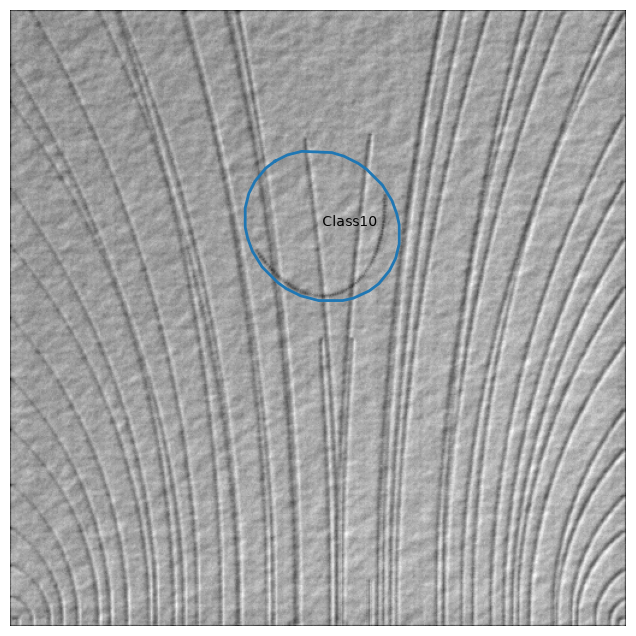

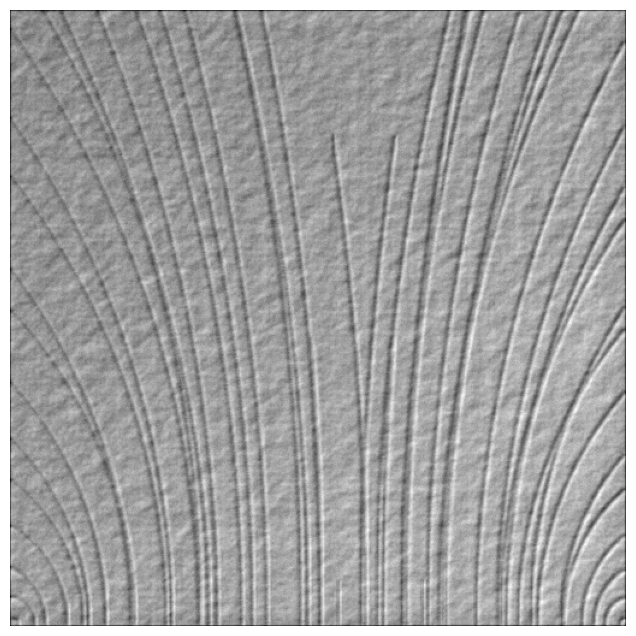

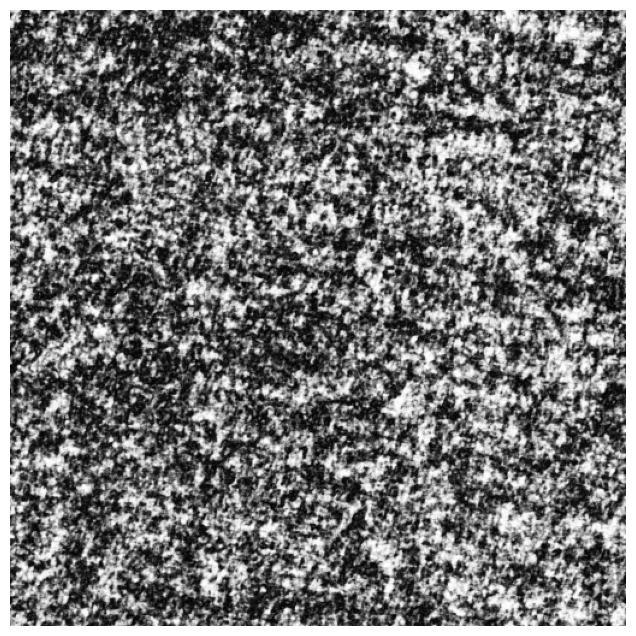

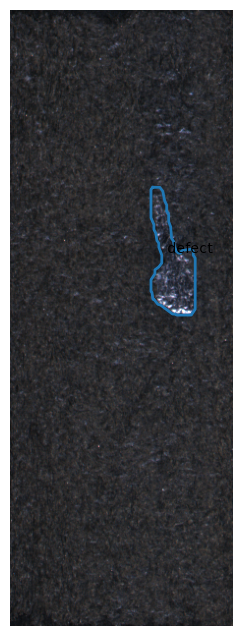

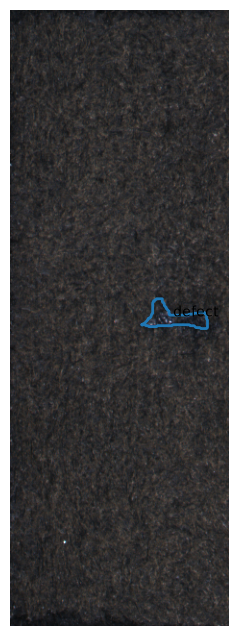

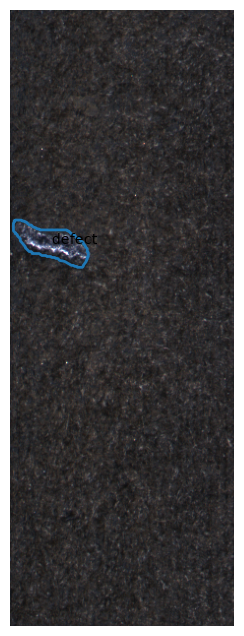

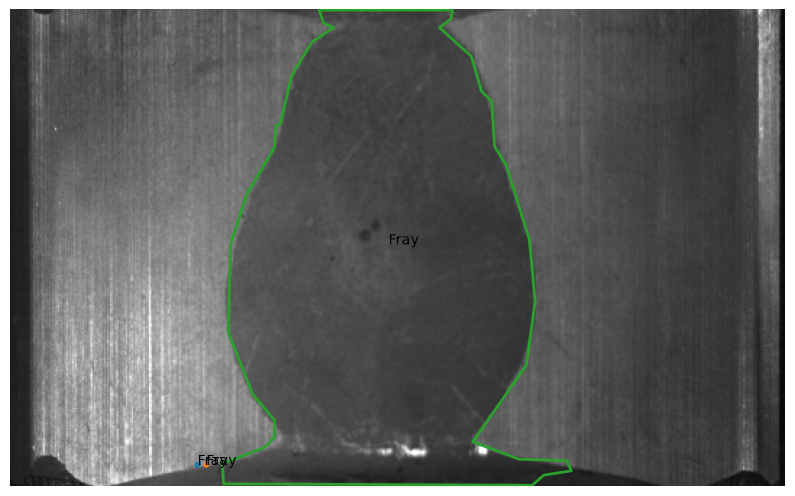

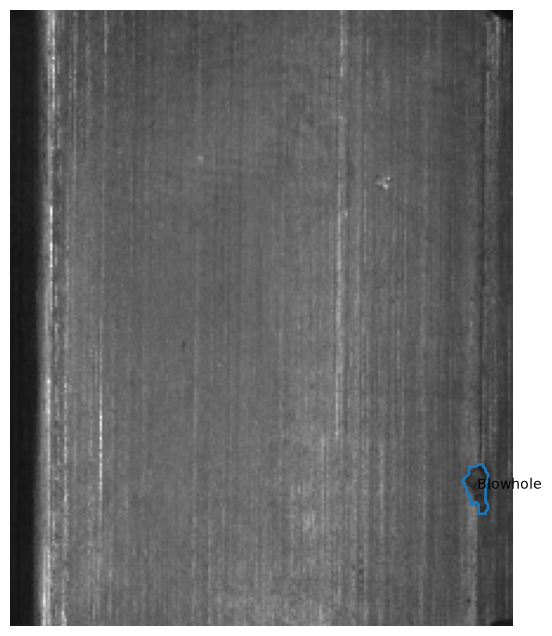

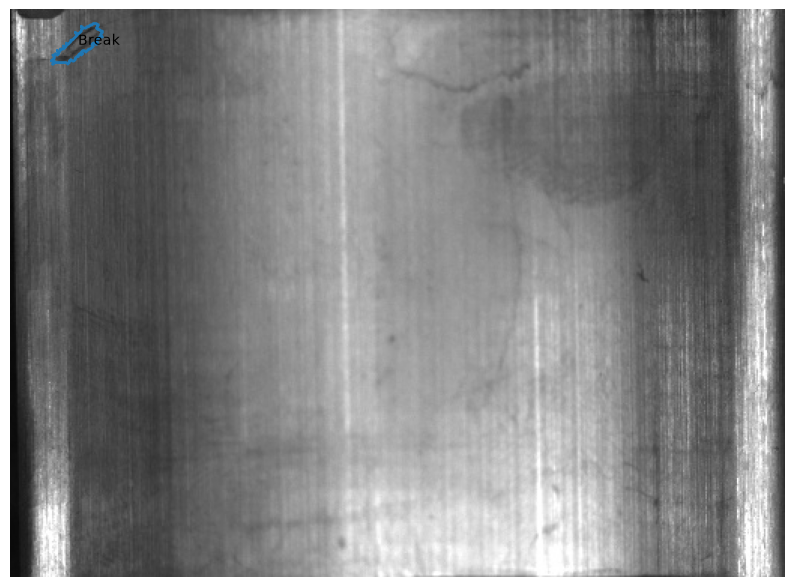

In [31]:
def read_yolo_label(path):
    text = Path(path).read_text(encoding="utf-8").strip()
    if not text:
        return []

    objects = []
    for line in text.splitlines():
        values = line.split()
        objects.append((
            int(values[0]),
            np.asarray([float(x) for x in values[1:]]).reshape(-1, 2)
        ))
    return objects


def visualize_yolo(image_path, label_path, class_names):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    plt.figure(figsize=(10, 8))
    plt.imshow(image)

    for class_id, polygon in read_yolo_label(label_path):
        pts = polygon.copy()
        pts[:, 0] *= w
        pts[:, 1] *= h
        pts = np.vstack([pts, pts[0]])

        plt.plot(pts[:, 0], pts[:, 1], linewidth=2)
        plt.text(
            pts[:-1, 0].mean(),
            pts[:-1, 1].mean(),
            class_names[class_id],
        )

    plt.axis("off")
    plt.show()


def inspect_dataset(name, n=3, seed=SEED):
    root = OUTPUT_ROOT / name
    report = conversion_results[name][1]
    positives = report[report["polygons"] > 0]

    if positives.empty:
        print("No positive samples:", name)
        return

    sample = positives.sample(min(n, len(positives)), random_state=seed)
    classes = datasets_to_convert[name][1]

    for row in sample.itertuples(index=False):
        visualize_yolo(row.image, row.label, classes)


inspect_dataset("DAGM", n=3)
inspect_dataset("KolektorSDD2", n=3)
inspect_dataset("Magnetic_Tile", n=3)


## 13. Save reports

In [32]:
for name, (_, report) in conversion_results.items():
    root = OUTPUT_ROOT / name
    errors, summary = validation[name]

    report.to_csv(root / "conversion_report.csv", index=False)
    errors.to_csv(root / "validation_errors.csv", index=False)
    summary.to_csv(root / "label_summary.csv", index=False)

print("YOLO datasets written to:", OUTPUT_ROOT.resolve())


YOLO datasets written to: /home/zubair/AI Development Directory/anomaly-detection/datasets/yolo_segmentation


# Final structure

```text
datasets/
└── yolo_segmentation/
    ├── DAGM/
    │   ├── images/
    │   │   ├── train/
    │   │   ├── val/
    │   │   └── test/
    │   ├── labels/
    │   │   ├── train/
    │   │   ├── val/
    │   │   └── test/
    │   ├── dataset.yaml
    │   ├── conversion_report.csv
    │   ├── label_summary.csv
    │   └── validation_errors.csv
    │
    ├── KolektorSDD2/
    │   └── ...
    │
    └── Magnetic_Tile/
        └── ...
```

### Important

The notebook deliberately does **not** delete or overwrite an existing generated dataset. If you change conversion parameters and rerun, delete:

```text
datasets/yolo_segmentation/
```

first.

**Next notebook:** `03_train_yolo_segmentation.ipynb` — baseline YOLO segmentation training and experiment tracking.
